# Proyecto final

In [54]:
# Librerias estandar
import pandas as pd
import numpy as np
import datasets 
import os
from tqdm.notebook import tqdm
import sklearn 
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
import time
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from datasets import Dataset
import random
import re
import matplotlib.patches as mpatches

# Librerias preprocesamiento
import spacy
from afinn import Afinn
afinn_dict = Afinn(language='en')._dict
import gensim.downloader as api

# Torch
from utils import TextClassifierRNN
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch

# Transformers
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    set_seed as set_transformer_seed
)
from langchain_ollama import ChatOllama

# Extra
import utils
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
def set_seed(seed):
    # 1. Python base y hashing
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    # 2. Computación numérica (NumPy)
    np.random.seed(seed)

    # 3. PyTorch (CPU y todas las GPUs)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # 4. Operaciones deterministas en la GPU (CuDNN y CuBLAS)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    torch.use_deterministic_algorithms(True, warn_only=True)

    # 5. Modelos de Hugging Face (Transformers)
    set_transformer_seed(seed)
set_seed(123)

### Datos 

In [26]:
dataset = datasets.load_dataset("sh0416/ag_news")
dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 7600
    })
})

In [27]:
train = pd.DataFrame(dataset["train"])
test = pd.DataFrame(dataset["test"])

print(f"Dimensiones train: {train.shape}")
print(f"Dimensiones test: {test.shape}")

print(f"\nTrain:")
train.sample(5)

Dimensiones train: (120000, 3)
Dimensiones test: (7600, 3)

Train:


,label,title,description
30870,2,"NHL on Ice, Maybe for Whole 2004-05 Season (AP)","AP - No shots, no saves, no goals. The Nationa..."
7738,2,Rowers to be punished for criticism of teammate,ROWER Sally Robbins #39;s teammates are expect...
25351,2,Changing Directions,"Over at USA Today -- Slogan: ""All the News Tha..."
74309,4,Cassini snapshots murky moon Titan,The Cassini probe got the first close-up photo...
88347,1,Farewell Yasser Arafat,"GAZA CITY, 12 November 2004 - The world will b..."


**Ejercicio 1**

Utilizando AG News, se deberán implementar y comparar varios sistemas y enfoques vistos a lo largo de la 
asignatura. En este ejercicio, la entrada del sistema deberá ser únicamente la columna **description**. La 
columna **title** **no** deberá utilizarse como parte del texto de entrada para clasificar.

In [28]:
# Seleccionamos lo necesario para este ejercicio
X_train = pd.DataFrame(train["description"])
y_train = pd.DataFrame(train["label"])

X_test = pd.DataFrame(test["description"])
y_test = pd.DataFrame(test["label"])

results_dict = {}

### Clasificación mediante lexicón

En primer lugar se va a utilizar un lexicón para hacer un análisis simple de sentimientos, calculando la puntuación de cada texto y clasificando utilizando el cero de umbral. Es el método más sencillo para clasificar y, por tanto, el que peores resultados debería tener. En este caso no se utilizará el conjunto de train, puesto que el modelo no requiere entrenamiento alguno.

In [29]:
# Inicializar spaCy 
try:
    # Intentar cargar el modelo
    print(f"Modelo ya desargado")
    nlp = spacy.load("en_core_web_sm")
    print(f"Modelo cargado")
except OSError:
    # Descargar si es necesario
    print(f"Descargando modelo...")
    os.system("python -m spacy download en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")
    print(f"Modelo cargado")
    
nlp = spacy.load("en_core_web_sm")

true_positives = 0

# Iteramos sobre cada texto 
for text in tqdm(X_test["description"].values, desc="Procesando textos"):
    # Tokenizar con spaCy
    doc = nlp(text)
    
    # Filtrar stopwords y puntuaciones, y obtener los strings limpios
    tokens_limpios = [token.text.lower() for token in doc if not token.is_stop and not token.is_punct]
    
    # Sustituir cada string por su valor en el diccionario de AFINN (0 si no existe)
    valores_afinn = [afinn_dict.get(word, 0) for word in tokens_limpios]
    
    # Pasar a np.array y realizar la suma
    suma = np.array(valores_afinn).sum()
    
    # Condición solicitada
    if suma >= 0:
        true_positives += 1

print(f"Accuracy: {true_positives/len(X_test)}")

results_dict["lexicon"] = true_positives/len(X_test)

Modelo ya desargado
Modelo cargado


Procesando textos:   0%|          | 0/7600 [00:00<?, ?it/s]

Accuracy: 0.6227631578947368


### Preprocesados textuales

Para los próximos modelos es esencial el pre-procesamiento de los textos. Para ello, se tokenizaran de cuatro formas distintas:

1. Tokenizacion 

2. Tokenización sin puntuaciones.

3. Tokenización sin stopwords.

4. Tokenizacion sin puntuaciones y sin stopwords.

In [30]:
# Ruta de datos 
data_dir = ".data"
os.makedirs(data_dir, exist_ok=True)

# Rutas a los diferents parquet
ficheros_train = [os.path.join(data_dir, f"X_train_{i}.parquet") for i in range(1, 5)]
ficheros_test = [os.path.join(data_dir, f"X_test_{i}.parquet") for i in range(1, 5)]

# Intentamos leer los datos si ya los tenemos guardados 
try:
    print("Intentando cargar las matrices optimizadas desde disco...")
    
    # Leemos y separamos en tokens
    X_train_1 = pd.read_parquet(ficheros_train[0]).iloc[:, 0].str.split()
    X_train_2 = pd.read_parquet(ficheros_train[1]).iloc[:, 0].str.split()
    X_train_3 = pd.read_parquet(ficheros_train[2]).iloc[:, 0].str.split()
    X_train_4 = pd.read_parquet(ficheros_train[3]).iloc[:, 0].str.split()

    X_test_1 = pd.read_parquet(ficheros_test[0]).iloc[:, 0].str.split()
    X_test_2 = pd.read_parquet(ficheros_test[1]).iloc[:, 0].str.split()
    X_test_3 = pd.read_parquet(ficheros_test[2]).iloc[:, 0].str.split()
    X_test_4 = pd.read_parquet(ficheros_test[3]).iloc[:, 0].str.split()
    print("Matrices cargadas y convertidas a listas de tokens correctamente.")

except (FileNotFoundError, Exception):
    print("Ficheros no encontrados o corruptos. Iniciando procesamiento con spaCy...")
    
    nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

    # Generar las matrices (devuelve Series de strings separados por espacios)
    X_train_1, X_train_2, X_train_3, X_train_4 = utils.procesar_matrices(X_train["description"], nlp)
    X_test_1, X_test_2, X_test_3, X_test_4 = utils.procesar_matrices(X_test["description"], nlp)

    print("Guardando matrices procesadas en formato Parquet...")
    # Guardamos el texto plano en el Parquet, es mas eficiente
    pd.DataFrame(X_train_1).to_parquet(ficheros_train[0])
    pd.DataFrame(X_train_2).to_parquet(ficheros_train[1])
    pd.DataFrame(X_train_3).to_parquet(ficheros_train[2])
    pd.DataFrame(X_train_4).to_parquet(ficheros_train[3])

    pd.DataFrame(X_test_1).to_parquet(ficheros_test[0])
    pd.DataFrame(X_test_2).to_parquet(ficheros_test[1])
    pd.DataFrame(X_test_3).to_parquet(ficheros_test[2])
    pd.DataFrame(X_test_4).to_parquet(ficheros_test[3])

    # Convertir las Series de strings a listas de tokens
    X_train_1, X_train_2, X_train_3, X_train_4 = X_train_1.str.split(), X_train_2.str.split(), X_train_3.str.split(), X_train_4.str.split()
    X_test_1, X_test_2, X_test_3, X_test_4 = X_test_1.str.split(), X_test_2.str.split(), X_test_3.str.split(), X_test_4.str.split()
    print("Proceso finalizado con éxito.")

Intentando cargar las matrices optimizadas desde disco...
Matrices cargadas y convertidas a listas de tokens correctamente.


In [31]:
X_train_dict = {
    "1": X_train_1,
    "2": X_train_2,
    "3": X_train_3,
    "4": X_train_4
}

X_test_dict = {
    "1": X_test_1,
    "2": X_test_2,
    "3": X_test_3,
    "4": X_test_4
}

In [32]:
print(f"Vamos a ver, para el primer documento de train, la diferencia de numero de tokens:\n"
      f" - Tokenizacion simple: {len(X_train_1[0])}\n"
      f" - Tokenizacion sin puntuaciones: {len(X_train_2[0])}\n"
      f" - Tokenizacion sin stopwords: {len(X_train_3[0])}\n"
      f" - Tokenizacion sin ambas: {len(X_train_4[0])}\n")

Vamos a ver, para el primer documento de train, la diferencia de numero de tokens:
 - Tokenizacion simple: 20
 - Tokenizacion sin puntuaciones: 14
 - Tokenizacion sin stopwords: 16
 - Tokenizacion sin ambas: 10



Hecho esto, ahora se tienen 4 dataframes por cada tipo de tokenización. La idea es comparar el desempeño de estos cuatro pre-procesamientos a la hora de clasificar. Se utilizarán tanto para la parte de representaciones dispersas y densas (machine learning tradicional) como para fine-tuninig (transformers).

### Representaciones dispersas y densas

#### Dispersas

Para las representaciones dispersas los modelos a probar son; Naives Bayes, regresión logística y SVM.

In [33]:
# Inicializar los diccionarios donde se guardarán las matrices BoW
X_train_BoW = {}
X_test_BoW = {}

# Iterar sobre las 4 configuraciones de tus datos
for key in tqdm(X_train_dict.keys(), desc="Vectorizando matrices BoW"):
    # Instanciar el vectorizador configurado para listas de tokens
    vectorizer = sklearn.feature_extraction.text.CountVectorizer(analyzer=lambda x: x, lowercase=False)
    
    # AJUSTAR y transformar con el conjunto de TRAIN
    X_train_BoW[key] = vectorizer.fit_transform(X_train_dict[key])
    
    # TRANSFORMAR el conjunto de TEST usando solo el vocabulario aprendido de TRAIN
    X_test_BoW[key] = vectorizer.transform(X_test_dict[key])

Vectorizando matrices BoW:   0%|          | 0/4 [00:00<?, ?it/s]

In [34]:
# Definimos hiperparametros para los ditintos modelos
models_and_params = {
    "NaiveBayes": {
        "model": MultinomialNB(),
        "params": {"alpha": [0.1, 1.0]}
    },
    "LogisticRegression": {
        "model": LogisticRegression(max_iter=200, solver="saga", tol=0.1), 
        "params": {"C": [0.1, 1.0]}
    },
    "SVM": {
        # dual=False es más rápido cuando n_samples > n_features
        "model": LinearSVC(max_iter=500, dual=False, tol=1e-3), 
        "params": {"C": [0.1, 1.0]}
    }
}

# Diccionario para almacenar los mejores modelos resultantes
best_models = {}

# Aplanar por seguridad
y_test_flat = y_test.values

for matrix_key in tqdm(X_train_BoW.keys(), desc="Evaluating text configurations"):
    X_train = X_train_BoW[matrix_key]
    # Extraer la matriz de test correspondiente a la configuración actual
    X_test_mat = X_test_BoW[matrix_key]
    y_train_flat = y_train.values.ravel()
    
    best_models[matrix_key] = {}
    
    # Bucle interno: itera sobre los modelos definidos
    for model_name, config in tqdm(models_and_params.items(), desc=f"GridSearch on Matrix {matrix_key}", leave=False):
        
        # Iniciar el cronómetro para este modelo
        start_time = time.time()
        
        grid = GridSearchCV(
            estimator=config["model"],
            param_grid=config["params"],
            cv=3,
            scoring="accuracy",
            n_jobs=-1
        )
        
        grid.fit(X_train, y_train_flat)
        
        # Guardar el mejor modelo entrenado
        best_model = grid.best_estimator_
        best_models[matrix_key][model_name] = best_model
        
        # Calcular el accuracy real utilizando el conjunto de test
        test_accuracy = best_model.score(X_test_mat, y_test_flat)
        
        # Calcular el tiempo transcurrido en segundos
        elapsed_time = time.time() - start_time
        
        # Guardar el accuracy de test con la nomenclatura solicitada
        key_name = f"{model_name}_{matrix_key}_BoW"
        results_dict[key_name] = float(test_accuracy)
        
        tqdm.write(f"-> Matrix {matrix_key} | {model_name} | Best Params: {grid.best_params_} | Test Accuracy: {test_accuracy:.4f} | Time: {elapsed_time:.2f}s")

Evaluating text configurations:   0%|          | 0/4 [00:00<?, ?it/s]

GridSearch on Matrix 1:   0%|          | 0/3 [00:00<?, ?it/s]

-> Matrix 1 | NaiveBayes | Best Params: {'alpha': 0.1} | Test Accuracy: 0.8962 | Time: 4.59s
-> Matrix 1 | LogisticRegression | Best Params: {'C': 1.0} | Test Accuracy: 0.8825 | Time: 6.13s
-> Matrix 1 | SVM | Best Params: {'C': 0.1} | Test Accuracy: 0.9125 | Time: 103.62s


GridSearch on Matrix 2:   0%|          | 0/3 [00:00<?, ?it/s]

-> Matrix 2 | NaiveBayes | Best Params: {'alpha': 0.1} | Test Accuracy: 0.8949 | Time: 0.42s
-> Matrix 2 | LogisticRegression | Best Params: {'C': 0.1} | Test Accuracy: 0.8939 | Time: 2.06s
-> Matrix 2 | SVM | Best Params: {'C': 0.1} | Test Accuracy: 0.9086 | Time: 85.39s


GridSearch on Matrix 3:   0%|          | 0/3 [00:00<?, ?it/s]

-> Matrix 3 | NaiveBayes | Best Params: {'alpha': 1.0} | Test Accuracy: 0.8955 | Time: 0.39s
-> Matrix 3 | LogisticRegression | Best Params: {'C': 1.0} | Test Accuracy: 0.8843 | Time: 2.23s
-> Matrix 3 | SVM | Best Params: {'C': 0.1} | Test Accuracy: 0.9113 | Time: 57.81s


GridSearch on Matrix 4:   0%|          | 0/3 [00:00<?, ?it/s]

-> Matrix 4 | NaiveBayes | Best Params: {'alpha': 1.0} | Test Accuracy: 0.8951 | Time: 0.37s
-> Matrix 4 | LogisticRegression | Best Params: {'C': 1.0} | Test Accuracy: 0.8958 | Time: 1.63s
-> Matrix 4 | SVM | Best Params: {'C': 0.1} | Test Accuracy: 0.9079 | Time: 39.22s


In [35]:
# Inicializar los diccionarios donde se guardarán las matrices TF-IDF
X_train_TFIDF = {}
X_test_TFIDF = {}

# Iterar sobre las 4 configuraciones de tus datos
for key in tqdm(X_train_dict.keys(), desc="Vectorizing TF-IDF matrices"):
    # Instanciar el vectorizador configurado para listas de tokens
    vectorizer = TfidfVectorizer(analyzer=lambda x: x, lowercase=False)
    
    # AJUSTAR y transformar con el conjunto de TRAIN
    X_train_TFIDF[key] = vectorizer.fit_transform(X_train_dict[key])
    
    # TRANSFORMAR el conjunto de TEST usando solo el vocabulario aprendido de TRAIN
    X_test_TFIDF[key] = vectorizer.transform(X_test_dict[key])

Vectorizing TF-IDF matrices:   0%|          | 0/4 [00:00<?, ?it/s]

In [36]:
# Diccionario para almacenar los mejores modelos resultantes de TF-IDF
best_models_tfidf = {}

# Asegurar que sea plano
y_test_flat = y_test.values.ravel()

# Bucle exterior: iterar por matriz 
for matrix_key in tqdm(X_train_TFIDF.keys(), desc="Evaluating TF-IDF configurations"):
    X_train = X_train_TFIDF[matrix_key]
    # Extraer la matriz de test correspondiente a la configuración actual
    X_test_mat = X_test_TFIDF[matrix_key]
    y_train_flat = y_train.values.ravel()
    
    best_models_tfidf[matrix_key] = {}
    
    # Bucle interior: iterar sobre los modelos
    for model_name, config in tqdm(models_and_params.items(), desc=f"GridSearch on TF-IDF Matrix {matrix_key}", leave=False):
        
        # Iniciar el cronómetro para este modelo
        start_time = time.time()
        
        grid = GridSearchCV(
            estimator=config["model"],
            param_grid=config["params"],
            cv=3,
            scoring="accuracy",
            n_jobs=-1
        )
        
        grid.fit(X_train, y_train_flat)
        
        # Guardar el mejor modelo entrenado
        best_model = grid.best_estimator_
        best_models_tfidf[matrix_key][model_name] = best_model
        
        # Calcular el accuracy real utilizando el conjunto de test
        test_accuracy = best_model.score(X_test_mat, y_test_flat)
        
        # Calcular el tiempo transcurrido en segundos
        elapsed_time = time.time() - start_time
        
        # Guardar el accuracy con la nomenclatura solicitada para TF-IDF
        key_name = f"{model_name}_{matrix_key}_TFIDF"
        results_dict[key_name] = float(test_accuracy)
        
        tqdm.write(f"-> Matrix {matrix_key} | {model_name} | Best Params: {grid.best_params_} | Test Accuracy: {test_accuracy:.4f} | Time: {elapsed_time:.2f}s")

Evaluating TF-IDF configurations:   0%|          | 0/4 [00:00<?, ?it/s]

GridSearch on TF-IDF Matrix 1:   0%|          | 0/3 [00:00<?, ?it/s]

-> Matrix 1 | NaiveBayes | Best Params: {'alpha': 0.1} | Test Accuracy: 0.8982 | Time: 0.42s
-> Matrix 1 | LogisticRegression | Best Params: {'C': 1.0} | Test Accuracy: 0.9084 | Time: 1.73s
-> Matrix 1 | SVM | Best Params: {'C': 0.1} | Test Accuracy: 0.9100 | Time: 24.32s


GridSearch on TF-IDF Matrix 2:   0%|          | 0/3 [00:00<?, ?it/s]

-> Matrix 2 | NaiveBayes | Best Params: {'alpha': 0.1} | Test Accuracy: 0.8971 | Time: 0.42s
-> Matrix 2 | LogisticRegression | Best Params: {'C': 1.0} | Test Accuracy: 0.9072 | Time: 1.79s
-> Matrix 2 | SVM | Best Params: {'C': 0.1} | Test Accuracy: 0.9087 | Time: 22.76s


GridSearch on TF-IDF Matrix 3:   0%|          | 0/3 [00:00<?, ?it/s]

-> Matrix 3 | NaiveBayes | Best Params: {'alpha': 1.0} | Test Accuracy: 0.8957 | Time: 0.38s
-> Matrix 3 | LogisticRegression | Best Params: {'C': 1.0} | Test Accuracy: 0.9067 | Time: 1.58s
-> Matrix 3 | SVM | Best Params: {'C': 0.1} | Test Accuracy: 0.9088 | Time: 18.86s


GridSearch on TF-IDF Matrix 4:   0%|          | 0/3 [00:00<?, ?it/s]

-> Matrix 4 | NaiveBayes | Best Params: {'alpha': 1.0} | Test Accuracy: 0.8947 | Time: 0.34s
-> Matrix 4 | LogisticRegression | Best Params: {'C': 1.0} | Test Accuracy: 0.9049 | Time: 1.57s
-> Matrix 4 | SVM | Best Params: {'C': 0.1} | Test Accuracy: 0.9084 | Time: 16.50s


Para todos los tipos de tokenización se puede observar que los resultados son básicamente idénticos. Sin embargo, los tiempos de entrenamiento varian muy considerablemente. En primer lugar, se puede ver como usar la matriz cuatro (sin puntuaciones y sin stopwords), si bien no incrementa la precision, baja mucho el tiempo de entrenamiento, es decir, que esa "informacion extra" que eliminamos es, para este dataset, inutil, por lo que se selecciona esta. 

Por otro lado, haciendo la comparación BoW vs TF-IDF, si bien no hay diferencias significativas de accuracy, si lo hay también en tiempos. A pesar de que a priori podría parecer que ambas son igual de buenas, dicha diferencia de tiempos nos sugiere lo contrario, ya que en ambas representaciones el tamaño de las matrices son iguales, por lo que un menor tiempo de entrenamiento implica una convergencia más rapida, lo que a su vez sugiere que la representación de los textos es mucho más informativa.

Por último, los tres tipos de modelos propuestos son igual de precisos en este dataset, pero el desempate se ve por tiempo de ejecución, donde Naives Bayes domina a los otros dos (sobre todo a SVM).

Antes de pasar con las densas, vamos a visualizar los resultados para que todo quede más claro, pero solo con los resultados de matriz 4, que se ha visto que es la representación más interesante.

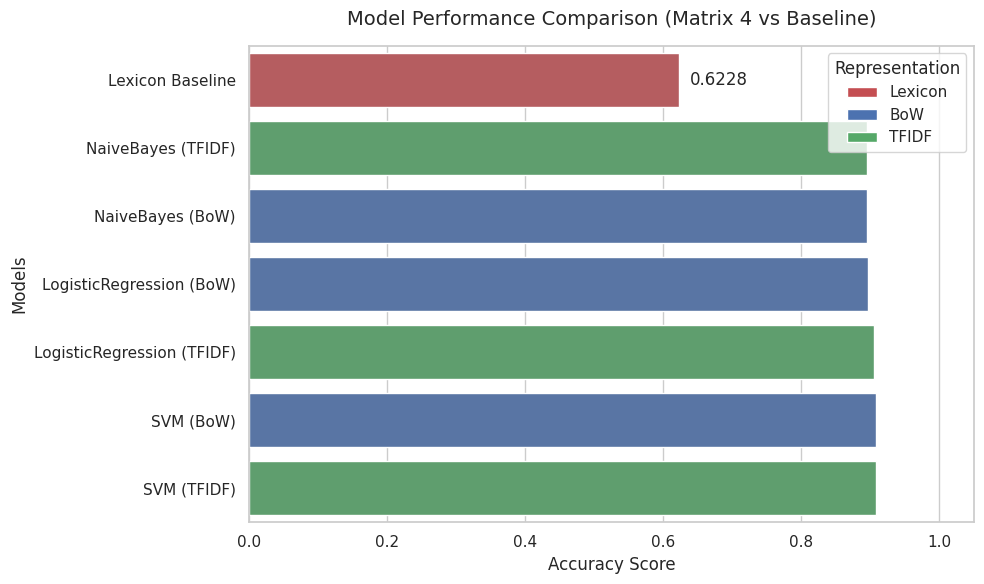

In [37]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Filtrar el diccionario y construir una estructura de datos limpia
plot_data = []

for key, accuracy in results_dict.items():
    if key == "lexicon":
        plot_data.append(
            {
                "Model_Matrix": "Lexicon Baseline",
                "Accuracy": accuracy,
                "Representation": "Lexicon",
            }
        )
    elif "_4_" in key:
        model_name = key.split("_")[0]
        representation = "BoW" if "BoW" in key else "TFIDF"

        plot_data.append(
            {
                "Model_Matrix": f"{model_name} ({representation})",
                "Accuracy": accuracy,
                "Representation": representation,
            }
        )

# Convertir a DataFrame de Pandas
df_plot = pd.DataFrame(plot_data)

# Ordenar por Accuracy para mejorar la lectura visual del gráfico
df_plot = df_plot.sort_values(by="Accuracy", ascending=True)

# 2. Configurar el estilo y los colores estáticos por fila
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Diccionario de colores asignados por tipo de representación
color_map = {"BoW": "#4C72B0", "TFIDF": "#55A868", "Lexicon": "#C44E52"}
# Crear una lista de colores emparejada uno a uno con el orden de las filas del DataFrame
bar_colors = [color_map[rep] for rep in df_plot["Representation"]]

# 3. Crear el gráfico de barras horizontales (sin hue para evitar duplicar textos)
ax = sns.barplot(
    x="Accuracy",
    y="Model_Matrix",
    data=df_plot,
    palette=bar_colors,  # Pasamos la lista exacta de colores asignados
)

# Ajustar límites del eje X
ax.set_xlim(0.0, 1.05)  # Un poco más de 1.0 para dar margen a la última etiqueta
ax.set_xlabel("Accuracy Score")
ax.set_ylabel("Models")
ax.set_title(
    "Model Performance Comparison (Matrix 4 vs Baseline)",
    fontsize=14,
    pad=15,
)

# Añadir las etiquetas de valor numérico sin duplicados
ax.bar_label(ax.containers[0], fmt="%.4f", padding=8)

# Añadir manualmente una leyenda dummy para mantener la referencia de colores
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="#C44E52", label="Lexicon"),
    Patch(facecolor="#4C72B0", label="BoW"),
    Patch(facecolor="#55A868", label="TFIDF"),
]
ax.legend(handles=legend_elements, title="Representation", loc="upper right")

plt.tight_layout()
plt.show()

Aqui ya se aprecia bien como no hay diferencias ni por modelo ni por tipo de representacion dispersa para estos modelos y este dataset.

#### Densas

Para las representaciones densas los modelos a probar son; regresión logística, SVM, LSTM estándar y GRU. 

En primer lugar, vamos a codificar los tokens por vocabulario.

In [38]:
# Diccionarios para almacenar las secuencias indexadas y con padding
X_train_seq = {}
X_test_seq = {}
vocabularies = {}  # Guardará el vocabulario asociado a cada configuración

# Calcular dinámicamente el tamaño máximo de secuencia sumando train y test
max_train = max(len(tokens) for tokens in X_train_dict["1"])
max_test = max(len(tokens) for tokens in X_test_dict["1"])
MAX_LEN = max(max_train, max_test)

# Construir el vocabulario
word_counts = Counter()
for tokens in X_train_dict["1"]:
    word_counts.update(tokens)

# Creamos el mapeo de palabra -> índice
# Reservamos el 0 para el Padding y el 1 para palabras desconocidas (OOV)
vocab = {"<PAD>": 0, "<UNK>": 1}
for word, _ in word_counts.items():
    vocab[word] = len(vocab)


# Función para indexar y aplicar padding/truncating a las secuencias
def encode_and_pad(token_lists, vocabulary, max_len):
    encoded_matrices = []
    for tokens in token_lists:
        # Convertir tokens a índices (usar 1 si no existe en el vocabulario de train)
        indices = [vocabulary.get(token, 1) for token in tokens]

        # Aplicar Truncating si excede max_len
        if len(indices) > max_len:
            indices = indices[:max_len]
        # Aplicar Padding con ceros si es más corto
        else:
            indices = indices + [0] * (max_len - len(indices))

        encoded_matrices.append(indices)
    return np.array(encoded_matrices, dtype=np.int64)


# Transformar los conjuntos de TRAIN y TEST para la matriz 1
X_train_seq = encode_and_pad(X_train_dict["1"], vocab, MAX_LEN)
X_test_seq = encode_and_pad(X_test_dict["1"], vocab, MAX_LEN)

print(
    f"Tamaños de secuencia:\n - Train: {X_train_seq.shape}\n - Test: {X_test_seq.shape}"
)

Tamaños de secuencia:
 - Train: (120000, 199)
 - Test: (7600, 199)


Codificación lista, ahora toca obtener los embeddings estaticos. Para esta tarea se van a utilizar GloVe y FastText. 

In [39]:
# Descargar los modelos preentrenados a través de gensim
print("Descargando vectores de GloVe...")
glove_model = api.load("glove-wiki-gigaword-100")

print("Descargando vectores de FastText...")
fasttext_model = api.load("fasttext-wiki-news-subwords-300")

# Dimensiones correspondientes a cada modelo descargado
embedding_dim_glove = 100
embedding_dim_fasttext = 300

# Inicializar las matrices de pesos con ceros
glove_matrix = np.zeros((len(vocab), embedding_dim_glove), dtype=np.float32)
fasttext_matrix = np.zeros(
    (len(vocab), embedding_dim_fasttext), dtype=np.float32
)

# Rellenar las matrices con los vectores del vocabulario aprendido en train
for word, idx in vocab.items():
    if word in ["<PAD>", "<UNK>"]:
        continue

    if word in glove_model:
        glove_matrix[idx] = glove_model[word]

    if word in fasttext_model:
        fasttext_matrix[idx] = fasttext_model[word]

Descargando vectores de GloVe...
Descargando vectores de FastText...


Para SVM y regresión logística necesitamos de entrada $$\text{docs} \times \text{num\_features}$$, pero al pasar por el embedding lo que obtenemos es $$\text{docs} \times \text{max\_len} \times \text{features}$$, es decir, un tensor tridimensional. Para poder pasarle a estos modelos los embeddings vamos a calcular la media de cada palabra. Para evitar el paso intermedio de tener un tensor gigante, vamos a realizar una equivalencia matemática: multiplicar la matriz BoW por la de pesos $$W$$. Esto hace lo siguiente:

$$(\text{docs} \times \text{vocab\_size}) \cdot (\text{vocab\_size} \times \text{embedding\_dim}) = (\text{docs} \times \text{embedding\_dim})$$

Por resumir un poco, lo que se hace aqui es calcular los embeddings de cada palabra y luego "resumir" el documento haciendo la media de todos los embeddings de sus palabras. Al multiplicar la matriz BOW (que contiene las frecuencias de cada palabra) por la de pesos $$W$$ directamente lo que se consigue es hacer la suma ponderada, por documento, de los embedding de las palabras. Si a esta matriz resultante se la divide por el numero de palabras de cada documento se obtiene la media de los embeddings de palabras por documento.

In [40]:
# Recalcular BoW para que coincidan los vocabularios 
vectorizer_dense = CountVectorizer(
    analyzer=lambda x: x, lowercase=False, vocabulary=vocab
)
X_train_counts = vectorizer_dense.transform(X_train_dict["1"]).astype(
    np.float32
)
X_test_counts = vectorizer_dense.transform(X_test_dict["1"]).astype(np.float32)

# Calcular longitud real de cada documento
train_lens = np.array(X_train_counts.sum(axis=1)) + 1e-9
test_lens = np.array(X_test_counts.sum(axis=1)) + 1e-9

# Calcular la media de los embeddings de GloVe por documento
X_train_glove_dense = np.array(X_train_counts @ glove_matrix) / train_lens
X_test_glove_dense = np.array(X_test_counts @ glove_matrix) / test_lens

# Calcular la media de los embeddings de FastText por documento
X_train_fasttext_dense = (
    np.array(X_train_counts @ fasttext_matrix) / train_lens
)
X_test_fasttext_dense = np.array(X_test_counts @ fasttext_matrix) / test_lens

print(
    f"Dimensiones de matrices:\n"
    f" - Train glove embedding {X_train_glove_dense.shape}\n"
    f" - Test glove embedding {X_test_glove_dense.shape}\n"
    f" - Train fasttext embedding {X_train_fasttext_dense.shape}\n"
    f" - Test fasttext embedding {X_test_fasttext_dense.shape}\n"
)

Dimensiones de matrices:
 - Train glove embedding (120000, 100)
 - Test glove embedding (7600, 100)
 - Train fasttext embedding (120000, 300)
 - Test fasttext embedding (7600, 300)



Ahora ya se tienen los dos embedding estaticos que vamos a probar para los diferentes modelos. Debido a que hay que usar diferentes apis, se van a probar primero SVM y Regresión Logística (sklearn) y luego ya LSTM y GRU (torch).

In [41]:
# Definimos hiperparametros para los ditintos modelos
models_and_params = {
    "LogisticRegression": {
        "model": LogisticRegression(max_iter=200, solver="saga", tol=0.1),
        "params": {"C": [0.1, 1.0]},
    },
    "SVM": {
        # dual=False es más rápido cuando n_samples > n_features
        "model": LinearSVC(max_iter=500, dual=False, tol=1e-3),
        "params": {"C": [0.1, 1.0]},
    },
}

# Diccionario para almacenar los mejores modelos resultantes
best_models_dense = {}

# Diccionarios intermedios para iterar por las configuraciones densas
X_train_dense_dict = {
    "glove": X_train_glove_dense,
    "fasttext": X_train_fasttext_dense,
}
X_test_dense_dict = {
    "glove": X_test_glove_dense,
    "fasttext": X_test_fasttext_dense,
}

# Aplanar por seguridad
y_test_flat = y_test.values

for matrix_key in tqdm(X_train_dense_dict.keys(), desc="Evaluating text configurations"):
    X_train = X_train_dense_dict[matrix_key]
    
    # Extraer la matriz de test correspondiente a la configuración actual
    X_test_mat = X_test_dense_dict[matrix_key]
    y_train_flat = y_train.values.ravel()

    best_models_dense[matrix_key] = {}

    # Bucle interno: itera sobre los modelos definidos
    for model_name, config in tqdm(
        models_and_params.items(),
        desc=f"GridSearch on Matrix {matrix_key}",
        leave=False,
    ):

        # Iniciar el cronómetro para este modelo
        start_time = time.time()

        grid = GridSearchCV(
            estimator=config["model"],
            param_grid=config["params"],
            cv=3,
            scoring="accuracy",
            n_jobs=-1,
        )

        grid.fit(X_train, y_train_flat)

        # Guardar el mejor modelo entrenado
        best_model = grid.best_estimator_
        best_models_dense[matrix_key][model_name] = best_model

        # Calcular el accuracy real utilizando el conjunto de test
        test_accuracy = best_model.score(X_test_mat, y_test_flat)

        # Calcular el tiempo transcurrido en segundos
        elapsed_time = time.time() - start_time

        # Guardar el accuracy de test con la nomenclatura solicitada
        key_name = f"{model_name}_{matrix_key}_Dense"
        results_dict[key_name] = float(test_accuracy)

        tqdm.write(
            f"-> Matrix {matrix_key} | {model_name} | Best Params: {grid.best_params_} | Test Accuracy: {test_accuracy:.4f} | Time: {elapsed_time:.2f}s"
        )

Evaluating text configurations:   0%|          | 0/2 [00:00<?, ?it/s]

GridSearch on Matrix glove:   0%|          | 0/2 [00:00<?, ?it/s]

-> Matrix glove | LogisticRegression | Best Params: {'C': 0.1} | Test Accuracy: 0.8628 | Time: 1.77s
-> Matrix glove | SVM | Best Params: {'C': 0.1} | Test Accuracy: 0.8738 | Time: 40.95s


GridSearch on Matrix fasttext:   0%|          | 0/2 [00:00<?, ?it/s]

-> Matrix fasttext | LogisticRegression | Best Params: {'C': 1.0} | Test Accuracy: 0.8614 | Time: 3.40s
-> Matrix fasttext | SVM | Best Params: {'C': 1.0} | Test Accuracy: 0.8757 | Time: 104.84s


Para las representaciones densas los resultados son ligeramente inferiores a las disperas. Al fin y al cabo, los documentos dispersos no tenian tantas columnas (199) por lo que las representaciones densas no ganan en compactación (de hecho, la de fasttext aumenta a 300). Además, en principio las representaciones densas deberían ser mas pontentes en modelos de Deep Learning. Por ello, como se ha dicho anteriormente, se van a probar para LSTM y GRU, donde, a priori, se debería obtener una mejora de rendimiento. En cuanto a los tiempos simivalres, la regresión tiempo bajo y el SVM más alto (sobre todo en fasttext, donde hay incluso más características que con las disperas, como se ha menciando hace un momento).

In [42]:
# Configurar el dispositivo (GPU si está disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo disponible: {device}")

# Generar secuencias con PRE-PADDING (ceros al principio) usando tu 'vocab'
X_train_seq_clean = np.array(
    [
        [0] * max(0, MAX_LEN - len(doc)) # Padding
        + [vocab.get(word, 1) for word in doc][:MAX_LEN] # Resto de tokens 
        for doc in X_train_dict["1"]
    ]
)
X_test_seq_clean = np.array(
    [
        [0] * max(0, MAX_LEN - len(doc))
        + [vocab.get(word, 1) for word in doc][:MAX_LEN]
        for doc in X_test_dict["1"]
    ]
)

# Corregir el desfase de las etiquetas para CrossEntropyLoss (rango 0 a 3)
y_train_clean = y_train.values.ravel() - 1
y_test_clean = y_test.values.ravel() - 1
NUM_CLASSES = len(np.unique(y_train_clean))

# Empaquetar en DataLoaders limpios
train_dataset = TensorDataset(
    torch.LongTensor(X_train_seq_clean), torch.LongTensor(y_train_clean)
)
test_dataset = TensorDataset(
    torch.LongTensor(X_test_seq_clean), torch.LongTensor(y_test_clean)
)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Definir las configuraciones de embeddings y arquitecturas a evaluar
embedding_configs = {
    "Random": {"weights": None, "dim": 100}, # Para el aprendible
    "GloVe": {"weights": torch.FloatTensor(glove_matrix), "dim": 100},
    "FastText": {"weights": torch.FloatTensor(fasttext_matrix), "dim": 300},
}

rnn_modes = ["lstm", "gru"]

# Parámetros fijos de entrenamiento
NUM_CLASSES = len(np.unique(y_train))
HIDDEN_DIM = 128
NUM_LAYERS = 1
EPOCHS = 3
LEARNING_RATE = 0.001

# Bucle principal sobre las configuraciones de Embedding
for emb_name, emb_meta in tqdm(embedding_configs.items(), desc="Evaluating Embeddings"):

    # Bucle interno sobre las arquitecturas RNN
    for mode in tqdm(rnn_modes, desc=f"Running RNNs for {emb_name}", leave=False):
        start_time = time.time()

        # Instanciar el modelo con la configuración correspondiente
        model = TextClassifierRNN(
            vocab_size=len(vocab),
            hidden_dim=HIDDEN_DIM,
            output_dim=NUM_CLASSES,
            mode=mode,
            num_layers=NUM_LAYERS,
            embedding_dim=emb_meta["dim"],
            pretrained_weights=emb_meta["weights"],
        ).to(device)

        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

        # Bucle de entrenamiento simplificado con métricas de Train
        for epoch in range(EPOCHS):
            model.train()
            correct_train = 0
            total_train = 0
            
            for texts, labels in train_loader:
                texts, labels = texts.to(device), labels.to(device)

                optimizer.zero_grad()
                outputs = model(texts)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
            

        # Evaluación en el conjunto de TEST
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for texts, labels in test_loader:
                texts, labels = texts.to(device), labels.to(device)
                outputs = model(texts)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        

        test_accuracy = correct / total
        elapsed_time = time.time() - start_time

        # Guardar el resultado en tu diccionario global con la misma nomenclatura
        key_name = f"{mode.upper()}_{emb_name.lower()}_Seq"
        results_dict[key_name] = float(test_accuracy)

        tqdm.write(
            f"-> Architecture: {mode.upper()} | Embedding: {emb_name} | Test Accuracy: {test_accuracy:.4f} | Time: {elapsed_time:.2f}s"
        )
        


Dispositivo disponible: cuda


Evaluating Embeddings:   0%|          | 0/3 [00:00<?, ?it/s]

Running RNNs for Random:   0%|          | 0/2 [00:00<?, ?it/s]

-> Architecture: LSTM | Embedding: Random | Test Accuracy: 0.8942 | Time: 46.88s
-> Architecture: GRU | Embedding: Random | Test Accuracy: 0.9021 | Time: 39.00s


Running RNNs for GloVe:   0%|          | 0/2 [00:00<?, ?it/s]

-> Architecture: LSTM | Embedding: GloVe | Test Accuracy: 0.9114 | Time: 29.67s
-> Architecture: GRU | Embedding: GloVe | Test Accuracy: 0.9151 | Time: 22.17s


Running RNNs for FastText:   0%|          | 0/2 [00:00<?, ?it/s]

-> Architecture: LSTM | Embedding: FastText | Test Accuracy: 0.8892 | Time: 36.07s
-> Architecture: GRU | Embedding: FastText | Test Accuracy: 0.8975 | Time: 29.22s


Los resultados son bastante similares a los obtenidos con los modelos más clásicos (ya eran muy buenos, superarlos es complicado). En cuanto a usar embbedings estaticos, GloVe es ligeramente mejor, pero en general no hay muchas diferencias en cuanto a precisión, pero si respecto a tiempo, ya que los embeddings no hay que aprenderlos/optimizarlos, solo realizar el producto matricial. 

### Fine-tuning de modelos basados en transformers

Ahora toca ir con algo más pontente: transformers. Por simplificar un poco, se va a simplemente bajar un modelo pre-entrenado para hacer el fine-tuning en nuestro conjunto de datos.

In [43]:
# Configurar dispositivo y limpiar etiquetas
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
y_train_clean = y_train.values.ravel() - 1
y_test_clean = y_test.values.ravel() - 1
NUM_CLASSES = len(np.unique(y_train_clean))

# Cargar el tokenizador de DistilRoBERTa (Mucho más rápido)
model_name = "distilbert/distilroberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

# Reconstruir los textos
train_texts = [
    " ".join(doc) if isinstance(doc, list) else doc for doc in X_train_dict["1"]
]
test_texts = [
    " ".join(doc) if isinstance(doc, list) else doc for doc in X_test_dict["1"]
]

# Crear Dataset de Hugging Face
train_dataset = Dataset.from_dict({"text": train_texts, "label": y_train_clean})
test_dataset = Dataset.from_dict({"text": test_texts, "label": y_test_clean})


def tokenize_function(examples):
    return tokenizer(
        examples["text"], padding="max_length", truncation=True, max_length=128
    )


train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": float(np.mean(predictions == labels))}


# Descargar 
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=NUM_CLASSES
).to(device)

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: distilbert/distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [44]:
# Hiperparámetros optimizados para velocidad en tu RTX 4060
training_args = TrainingArguments(
    output_dir="./results_distilroberta",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=10,
    bf16=True,  # Mantenemos bf16 para exprimir los Tensor Cores de la 4060
    report_to="none",
)

# Inicializar el Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

# Entrenar (Fine-tuning rápido)
start_time = time.time()
trainer.train()

# Evaluar
metrics = trainer.evaluate()
elapsed_time = time.time() - start_time

test_accuracy = metrics["eval_accuracy"]
results_dict["DistilRoBERTa_Transformer"] = float(test_accuracy)

print(f"\n==================================================")
print(
    f"-> Model: DistilRoBERTa | Test Accuracy: {test_accuracy:.4f} | Time: {elapsed_time:.2f}s"
)
print(f"==================================================")

Epoch,Training Loss,Validation Loss,Accuracy
1,0.193584,0.234315,0.926579
2,0.166243,0.232572,0.934342
3,0.154950,0.246213,0.937105


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy
0.154950,0.232572,3,0.934342



-> Model: DistilRoBERTa | Test Accuracy: 0.9343 | Time: 1214.88s


Este modelo (como cabia esperar) ha reportado un mejor accuracy en test (la mayoría de los anteriores rondaba el 0.9, y este se pone en cabeza con alrededor de 0.92-0.93). Sin embargo, el tiempo de entrenamiento ha sido muy superior (alrededor de 18-20 minutos). Para este dataset en concreto, realmente apenas hay mejora para la diferencia de tiempo tan grande, pero en otros datasets más complejos la diferencia en accuracy probablemente sería mucho más pronunciada.

### Clasificación utilizando LLMs y promting

Por último, se va a realizar la clasificación con un enfoque distinto: en vez de entrenar (o afinar) modelos cuyo output es la clase, se va a utilizar un LLM para que clasifique los textos. El modelo se cargara y sus pesos se quedarán intáctos, se intentará obtener buenos resultados solo via promting.

In [51]:
# Inicializar el cliente local de Ollama (Gemma2 a temperatura 0)
llm = ChatOllama(model="gemma2", temperature=0) #type:ignore

# Limpiar las etiquetas de test para el cálculo del Accuracy
y_test_clean_full = y_test.values.ravel() - 1

# Reconstruir los textos de test uniendo los tokens si vienen en formato lista
test_texts_full = np.array([" ".join(doc) if isinstance(doc, list) else doc for doc in X_test_dict["1"]])

# Generar submuestra aleatoria de 100 índices para acelerar la inferencia
indices_aleatorios = np.random.choice(len(test_texts_full), size=500, replace=False)
test_texts = test_texts_full[indices_aleatorios]
y_test_clean = y_test_clean_full[indices_aleatorios]

# Ejemplos con etiquetas semánticas para el prompt
example = """(0) -> Spanish police detain several suspected Islamic militants in a series of pre-dawn raids in Barcelona.
(2) -> RUPERT MURDOCHS News Corp media empire has posted a 28 per cent rise in quarterly profit as strong results in newspapers, broadcast and cable television countered weaker performances in its film and Italian pay-TV divisions.
(1) -> Ralph Friedgen used a four-letter word to describe his Maryland team's offensive performance in Sunday's practice: blah.
(3) -> Game invites users to play the role of JFK's assassin, causing some observers to wonder whether video games have gone too far."""

# Función simplificada para crear los mensajes en la estructura de LangChain
def build_messages(text):
    prompt_content = (
        "You are an expert, high-precision text classifier.\n"
        "Your task is to classify the input text into one of the following numerical categories:\n"
        "0: World\n"
        "1: Sports\n"
        "2: Business\n"
        "3: Sci/tech\n\n"
        "Here are some examples to help you understand the classes:\n"
        f"{example}\n\n"
        "STRICT RULE: Respond ONLY with the integer number (0, 1, 2, or 3) that corresponds to the text category. "
        "Only write the digit.\n\n"
        f"Text to classify: {text}\n"
        "Category number:"
    )
    return [("user", prompt_content)]

# Bucle de inferencia con LangChain
y_pred_llm = []
start_time = time.time()

for text in tqdm(test_texts, desc="Ollama Gemma2 Inference"):
    messages = build_messages(text)
    
    # Invocamos el modelo; LangChain nos devuelve un AIMessage directamente
    response = llm.invoke(messages)
    generated_text = response.content.strip() #type:ignore
    
    # Extraer el primer dígito válido (0, 1, 2 o 3)
    match = re.search(r'[0-3]', generated_text)
    if match:
        pred_class = int(match.group())
    else:
        pred_class = 0  # Fallback
        
    y_pred_llm.append(pred_class)

# Calcular métricas finales
elapsed_time = time.time() - start_time
y_pred_llm = np.array(y_pred_llm)
test_accuracy = float(np.mean(y_pred_llm == y_test_clean))

results_dict["Gemma2_Ollama_Prompting"] = test_accuracy

print(f"\n==================================================")
print(f"-> Model: Gemma2 (Ollama) | Test Accuracy: {test_accuracy:.4f} | Time: {elapsed_time:.2f}s")
print(f"==================================================")

Ollama Gemma2 Inference:   0%|          | 0/500 [00:00<?, ?it/s]


-> Model: Gemma2 (Ollama) | Test Accuracy: 0.8200 | Time: 544.18s


En este caso ha habido un downgrade de los resultados significativo. Al fin y al cabo tampoco es algo inesperado, puesto que mientras que los otros modelos se especializan en clasificar las clases del dataset, este método sin embargo tiene que confiar en el entendimiento del lenguaje que tenga el LLM. 

Por otro lado, el tiempo de ejecución es infinitamente mayor. Se ha tenido que usar un subconjuto de test (500 de 7600 muestras) para evitar esperar mucho. Con esta cantidad la inferencia (solo inferencia, recordemos que en los otros modelos lo que tardaba era el entrenamiento, la inferencia era casi instantanea) el modelo ha tardado unos 3.36 min en clasificar los 500 textos, por lo que en clasificar todo el conjuto de test habria 15-16 veces más de tiempo (alrededor de 45 minutos). Esta claro que, para este dataset, este método es del todo menos eficiente. NaivesBayes realizaba la clasificación con 0.9 de accuracy en menos de 5 segundos. 

### Resultados

Para terminar el primer ejercicio, se van a comparar los resultados de todas las secciones visualmente. Para ello se seleccionarán, por sección, aquellos modelos que mejores resultados hayan tenido.

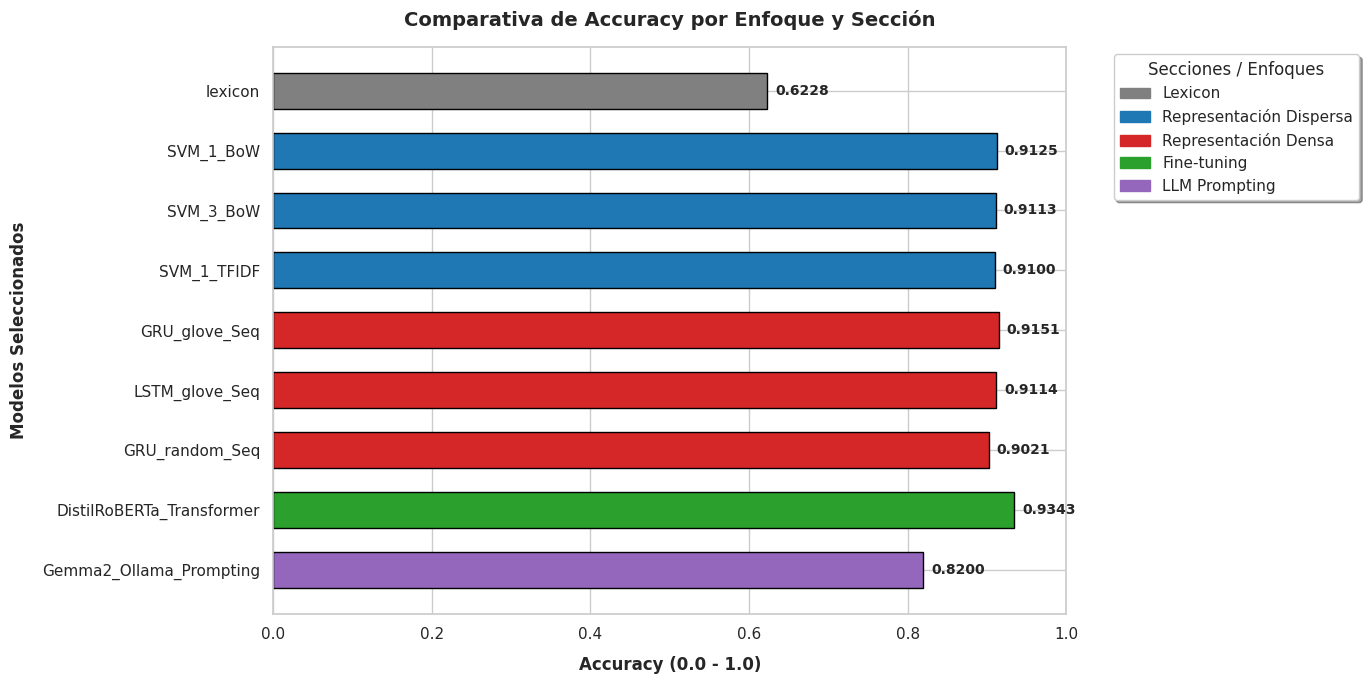

In [ ]:
# Seleccionamos los modelos
selected_models = [
    # Lexicon
    "lexicon",
    # Dispersa
    "SVM_1_BoW",
    "SVM_3_BoW",
    "SVM_1_TFIDF",
    # Densa
    "GRU_glove_Seq",
    "LSTM_glove_Seq",
    "GRU_random_Seq",
    # Fine-tuning
    "DistilRoBERTa_Transformer",
    # LLM promting
    "Gemma2_Ollama_Prompting",
]

# Representamos
accuracies = [results_dict.get(m, 0.0) for m in selected_models]

# Asignación estricta de colores según la sección del modelo
colores = [
    "gray",  # Lexicon
    "#1f77b4",
    "#1f77b4",
    "#1f77b4",  # Representación Dispersa (Azul)
    "#d62728",
    "#d62728",
    "#d62728",  # Representación Densa (Rojo)
    "#2ca02c",  # Fine-tuning (Verde)
    "#9467bd",  # LLM Prompting (Morado)
]

# Configurar el estilo y crear la figura
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# Crear el gráfico de barras horizontales (barh)
bars = plt.barh(
    selected_models, accuracies, color=colores, edgecolor="black", height=0.6
)

# Configurar límites y etiquetas de los ejes
plt.xlim(0.0, 1.0)
plt.xlabel("Accuracy (0.0 - 1.0)", fontsize=12, fontweight="bold", labelpad=10)
plt.ylabel("Modelos Seleccionados", fontsize=12, fontweight="bold", labelpad=10)
plt.title(
    "Comparativa de Accuracy por Enfoque y Sección",
    fontsize=14,
    fontweight="bold",
    pad=15,
)

# Invertir el eje Y para que el léxicon (primero de la lista) aparezca arriba del todo
plt.gca().invert_yaxis()

# Añadir los valores numéricos de accuracy al final de cada barra de forma limpia
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,  # Desfase en X para que no toque la línea de la barra
        bar.get_y() + bar.get_height() / 2,  # Centrado vertical
        f"{width:.4f}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
    )


plt.legend(
    title="Secciones / Enfoques",
    loc="lower right",
    frameon=True,
    shadow=True,
)

# Legenda colocada fuera del gráfico a la derecha
legend_patches = [
    mpatches.Patch(color="gray", label="Lexicon"),
    mpatches.Patch(color="#1f77b4", label="Representación Dispersa"),
    mpatches.Patch(color="#d62728", label="Representación Densa"),
    mpatches.Patch(color="#2ca02c", label="Fine-tuning"),
    mpatches.Patch(color="#9467bd", label="LLM Prompting"),
]
plt.legend(
    handles=legend_patches,
    title="Secciones / Enfoques",
    loc="upper left",
    bbox_to_anchor=(1.05, 1), 
    frameon=True,
    shadow=True,
)

# Ajustar el diseño para evitar que se corten los nombres largos de la izquierda
plt.tight_layout()
plt.show()

Finalmente, modelo que mejor resultados a reportado ha sido el transformer *DistilRoBERTa* con 0.93 de accuracy, seguido de cerca de la mayoría de modelos a excepción del lexicón y del LLM con promting. 

Como conclusión se puede sacar que, en general, es mejor una solución específica para cada problema a una más genérica. Sin embargo, en datos más complejos los modelos que no estan basados en transformers (sobre todo las RNN) podrían reducir bastante su rendimiento, pero en el caso de este dataset no sucede. Si los datos tuviesen un lenguaje más complejo, es posible que la capacidad de los transformers para captar la sémantica hiciese que el rendimiento se mantuviese.

Cabe destacar además que, para textos más largos, las arquitecturas de RNN acabarían sufriendo el desvanecimiento de gradiente, por lo que su rendimiento caería bastate. 